# Breast Cancer Tumor Classification

## Objective

The goal of this project is to build a machine learning classification model that predicts whether a tumor is **benign** or **malignant** based on numeric tumor measurements.

This project follows the required machine learning workflow:

1. Dataset selection
2. Exploratory Data Analysis
3. Data cleaning and preprocessing
4. Model training
5. Model evaluation
6. Model saving for deployment

## 1. Import Libraries

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Load the Dataset

The dataset used is the Breast Cancer Wisconsin dataset from scikit-learn. This is a binary classification dataset where the target is either benign or malignant.

In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Dataset Overview

In [3]:
print("Dataset shape:", df.shape)
print("Number of features:", X.shape[1])
print("Target names:", data.target_names)
print("Feature names:")
print(list(X.columns))

Dataset shape: (569, 31)
Number of features: 30
Target names: ['malignant' 'benign']
Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 4. Exploratory Data Analysis

In this section, we check the target distribution, missing values, descriptive statistics, feature distributions, and correlation between features.

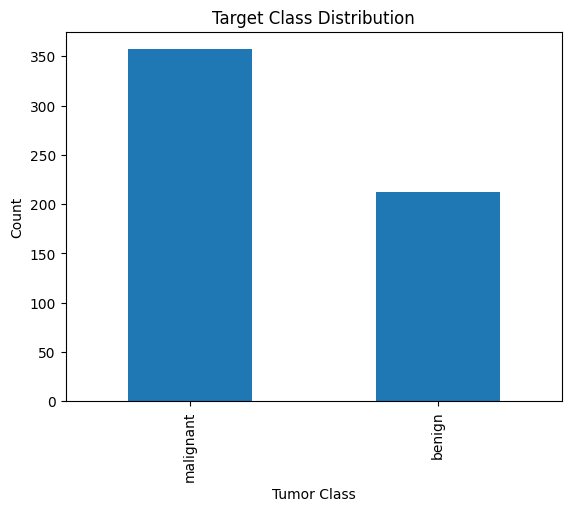

,count
malignant,357
benign,212


In [6]:
target_counts = y.value_counts()
target_counts.index = data.target_names

target_counts.plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Count")
plt.show()

target_counts

In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


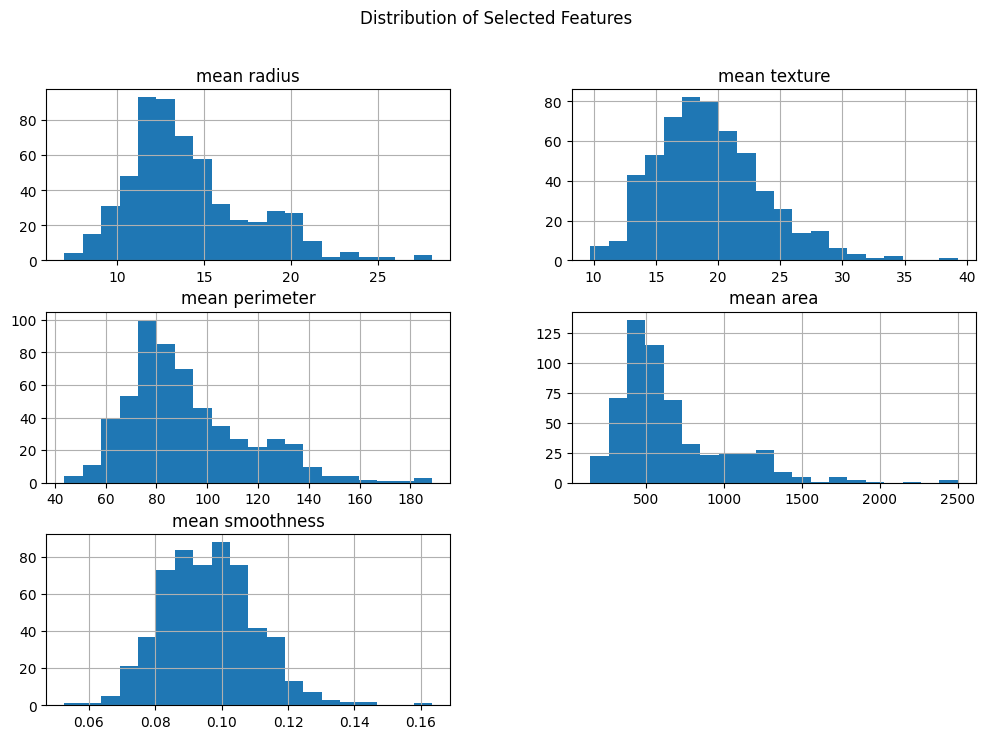

In [8]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
]

df[selected_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of Selected Features")
plt.show()

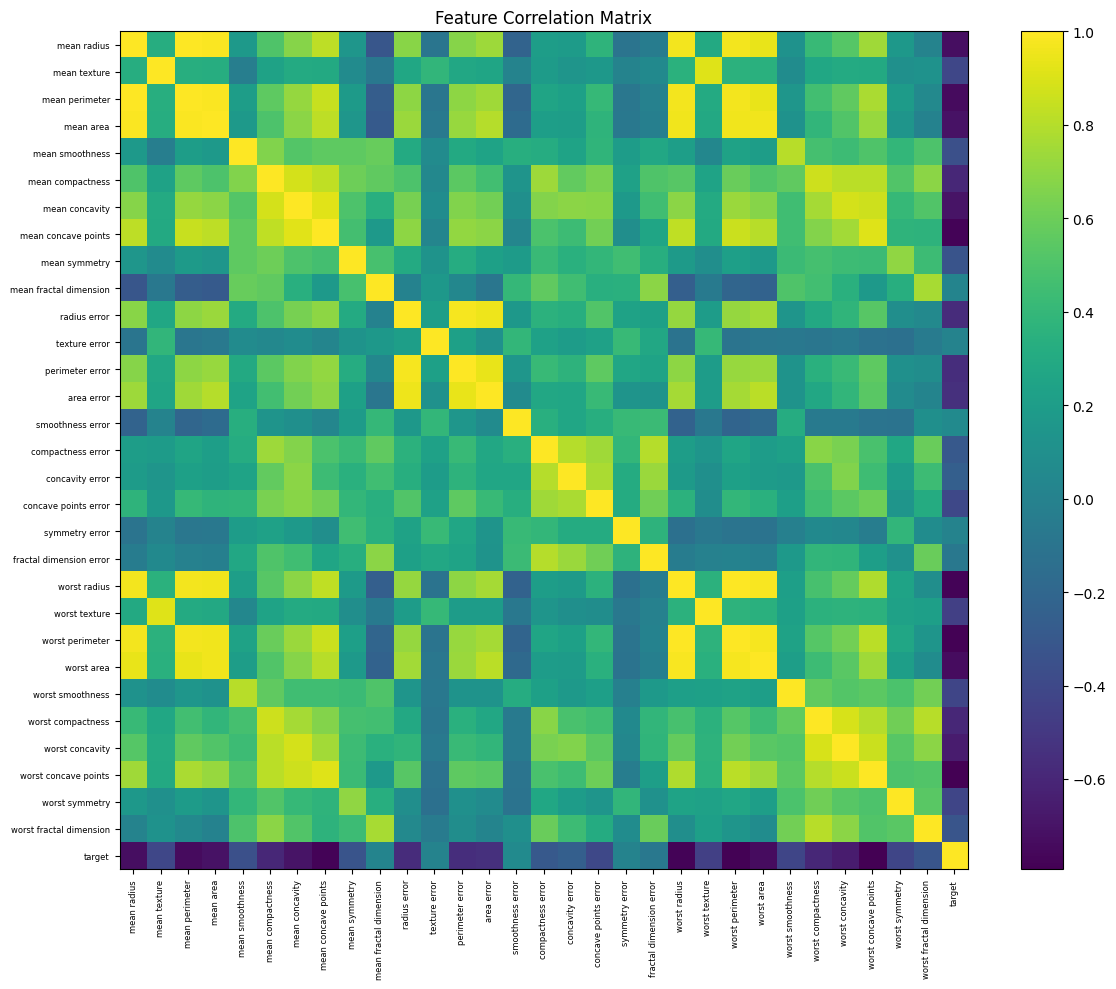

In [9]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90, fontsize=6)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, fontsize=6)
plt.tight_layout()
plt.show()

## 5. Data Cleaning and Preprocessing

The dataset is already clean and contains no missing values. However, preprocessing is still needed because Logistic Regression is sensitive to feature scales.

Preprocessing steps:

1. Separate features and target
2. Split the data into training and testing sets
3. Scale features using `StandardScaler`
4. Train Logistic Regression inside a Pipeline

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


## 6. Train the Machine Learning Model

In [11]:
model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=5000, random_state=42)),
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=42))])

## 7. Model Evaluation

Since this is a classification problem, the model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report

In [12]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Score"])
metrics_df

,Metric,Score
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,F1-score,0.986111
4,ROC-AUC,0.995370


In [13]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in data.target_names],
    columns=[f"Predicted {name}" for name in data.target_names],
)
cm_df

,Predicted malignant,Predicted benign
Actual malignant,41,1
Actual benign,1,71


In [14]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



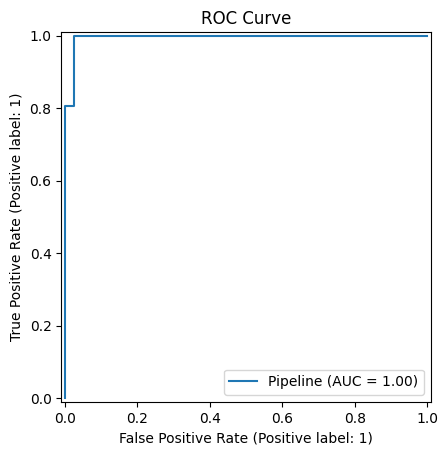

In [15]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

## 8. Save the Trained Model

The trained model is saved using `joblib` so it can be used later in the Streamlit app.

In [16]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(
    {
        "model": model,
        "feature_names": list(X.columns),
        "target_names": list(data.target_names),
    },
    "../models/model.joblib",
)

print("Model saved successfully.")

Model saved successfully.


## 9. Conclusion

This project successfully built a binary classification model to classify breast tumors as benign or malignant.

The final model uses a pipeline with feature scaling and Logistic Regression. It was evaluated using several classification metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC, and a Confusion Matrix.

The model is also prepared for deployment using a Streamlit web app.